In [1]:
import pandas as pd

df = pd.read_csv('aice_day6_customer_churn.csv')

In [2]:
df.head()

,customer_id,age,gender,city,tenure_months,monthly_fee,contract_type,support_calls,late_payments,usage_hours,churn
0,C1001,23.0,M,Daegu,47,36.85,Monthly,2,0,64.7,0
1,C1002,59.0,M,Busan,61,70.96,Monthly,2,0,95.5,0
2,C1003,53.0,M,Daegu,61,60.97,Monthly,6,0,95.4,1
3,C1004,41.0,F,Daegu,62,101.26,Monthly,0,1,91.6,0
4,C1005,41.0,M,Incheon,46,64.86,Monthly,3,1,72.3,0


In [3]:
df.isnull().sum()

customer_id       0
age              12
gender            0
city              0
tenure_months     0
monthly_fee       8
contract_type     0
support_calls     0
late_payments     0
usage_hours       0
churn             0
dtype: int64

In [4]:
df['age'].describe()

count    208.000000
mean      45.360577
std       14.402421
min       19.000000
25%       33.750000
50%       45.000000
75%       58.000000
max       70.000000
Name: age, dtype: float64

In [5]:
# 결측치 처리
df['age'] = df['age'].fillna(df['age'].median())
df['monthly_fee'] = df['monthly_fee'].fillna(df['monthly_fee'].median())

In [6]:
df.isnull().sum()

customer_id      0
age              0
gender           0
city             0
tenure_months    0
monthly_fee      0
contract_type    0
support_calls    0
late_payments    0
usage_hours      0
churn            0
dtype: int64

In [7]:
# 범주형 처리
df['gender'] = df['gender'].map({'M':0,'F':1})
df = pd.get_dummies(df, columns=['city'])

In [8]:
df['contract_type'].value_counts()

contract_type
Monthly    123
OneYear     52
TwoYear     45
Name: count, dtype: int64

In [9]:
df = pd.get_dummies(df, columns=['contract_type'])

In [10]:
df.head()

,customer_id,age,gender,tenure_months,monthly_fee,support_calls,late_payments,usage_hours,churn,city_Busan,city_Daegu,city_Incheon,city_Seoul,contract_type_Monthly,contract_type_OneYear,contract_type_TwoYear
0,C1001,23.0,0,47,36.85,2,0,64.7,0,False,True,False,False,True,False,False
1,C1002,59.0,0,61,70.96,2,0,95.5,0,True,False,False,False,True,False,False
2,C1003,53.0,0,61,60.97,6,0,95.4,1,False,True,False,False,True,False,False
3,C1004,41.0,1,62,101.26,0,1,91.6,0,False,True,False,False,True,False,False
4,C1005,41.0,0,46,64.86,3,1,72.3,0,False,False,True,False,True,False,False


In [11]:
# x, y / train,test 분리
from sklearn.model_selection import train_test_split

x = df.drop(columns=['customer_id','churn'])
y = df['churn']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [12]:
# 모델 생성
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [13]:
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [14]:
# 혼동행렬 및 예측 점수
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix

confusion = confusion_matrix(y_test, y_pred)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(confusion)
print(acc)
print(prec)
print(recall)
print(f1)

[[35  0]
 [ 9  0]]
0.7954545454545454
0.0
0.0
0.0


c:\Users\LSG\Desktop\AICE\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [15]:
balanced_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced' # 클래스 빈도에 반비례해서 가중치를 자동으로 계산한다
)

balanced_model.fit(x_train, y_train)
balanced_pred = balanced_model.predict(x_test)

b_confusion = confusion_matrix(y_test, balanced_pred)

b_acc = accuracy_score(y_test, balanced_pred)
b_prec = precision_score(y_test, balanced_pred)
b_recall = recall_score(y_test, balanced_pred)
b_f1 = f1_score(y_test, balanced_pred)

print(b_confusion)
print(b_acc)
print(b_prec)
print(b_recall)
print(b_f1)


[[32  3]
 [ 6  3]]
0.7954545454545454
0.5
0.3333333333333333
0.4


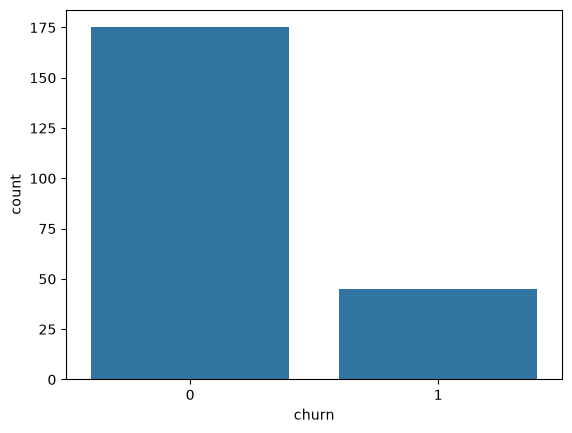

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='churn')
plt.show()

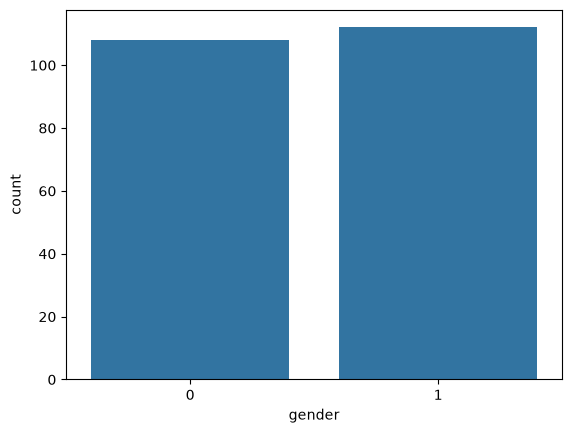

In [17]:
sns.countplot(data=df, x='gender')
plt.show()

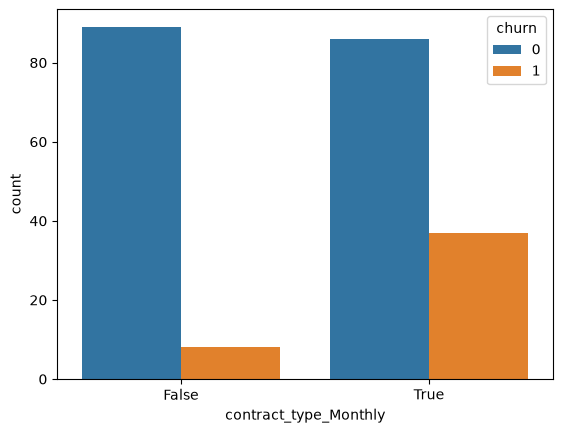

In [18]:
sns.countplot(
    data=df,
    x='contract_type_Monthly',
    hue='churn'
)

plt.show()

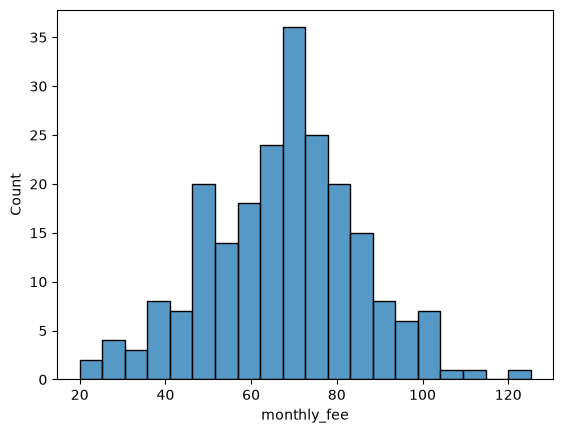

In [19]:
sns.histplot(
    data=df, 
    x='monthly_fee',
    bins=20
)

plt.show()

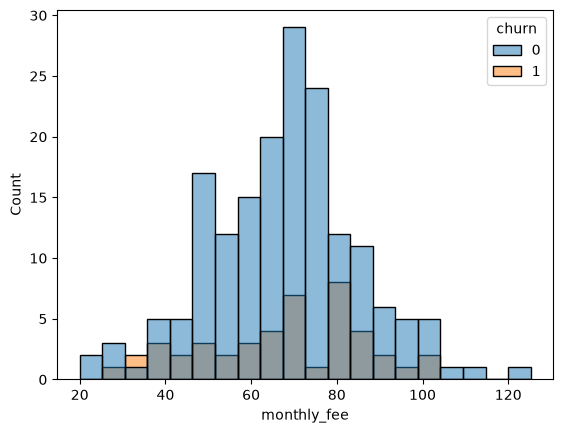

In [20]:
sns.histplot(
    data=df,
    x='monthly_fee',
    hue='churn',
    bins=20
)

plt.show()

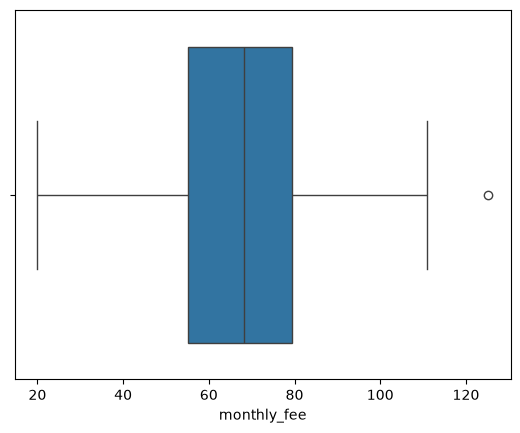

In [21]:
sns.boxplot(
    data=df,
    x='monthly_fee'
)

plt.show()

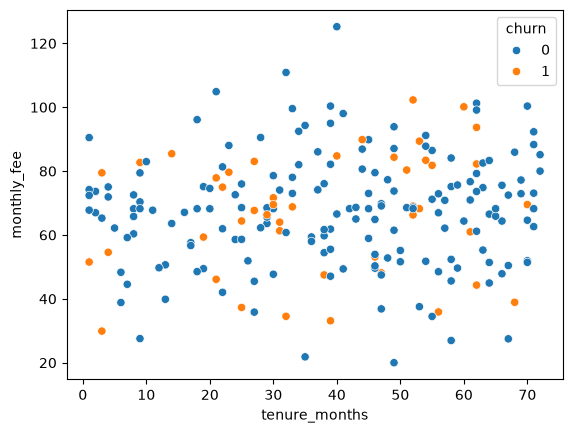

In [22]:
sns.scatterplot(
    data=df,
    x='tenure_months',
    y='monthly_fee',
    hue='churn'
)

plt.show()

In [23]:
#상관계수 계산
corr = df.corr(numeric_only=True)
corr

,age,gender,tenure_months,monthly_fee,support_calls,late_payments,usage_hours,churn,city_Busan,city_Daegu,city_Incheon,city_Seoul,contract_type_Monthly,contract_type_OneYear,contract_type_TwoYear
age,1.000000,0.040233,0.037954,0.047495,-0.040726,-0.009287,0.006631,-0.045445,-0.023508,-0.054466,0.179959,-0.060791,-0.043206,0.000975,0.052154
gender,0.040233,1.000000,-0.154638,0.029114,-0.117048,0.113735,0.016194,0.069673,-0.100479,0.052597,-0.020525,0.069601,-0.011321,-0.052920,0.069673
tenure_months,0.037954,-0.154638,1.000000,0.081115,0.024707,-0.039780,0.042009,-0.043984,-0.021858,-0.018700,0.009098,0.028872,0.029997,-0.064292,0.030794
monthly_fee,0.047495,0.029114,0.081115,1.000000,-0.022405,0.040899,0.034971,-0.012805,0.004949,-0.033864,-0.039795,0.048945,0.036461,-0.023224,-0.020418
support_calls,-0.040726,-0.117048,0.024707,-0.022405,1.000000,0.113108,0.004208,0.227139,-0.001659,-0.092631,0.006828,0.067993,-0.035666,0.072489,-0.032448
late_payments,-0.009287,0.113735,-0.039780,0.040899,0.113108,1.000000,-0.099842,0.187061,0.062195,-0.104583,0.087828,-0.039948,0.043483,-0.117732,0.070479
usage_hours,0.006631,0.016194,0.042009,0.034971,0.004208,-0.099842,1.000000,-0.070962,0.094627,-0.089378,0.003706,-0.024087,0.001680,-0.010915,0.009428
churn,-0.045445,0.069673,-0.043984,-0.012805,0.227139,0.187061,-0.070962,1.000000,-0.124198,-0.047246,0.035582,0.129917,0.268747,-0.176024,-0.145397
city_Busan,-0.023508,-0.100479,-0.021858,0.004949,-0.001659,0.062195,0.094627,-0.124198,1.000000,-0.303956,-0.263402,-0.536388,-0.129783,0.062052,0.094390
city_Daegu,-0.054466,0.052597,-0.018700,-0.033864,-0.092631,-0.104583,-0.089378,-0.047246,-0.303956,1.000000,-0.175209,-0.356794,0.130062,-0.107138,-0.047246


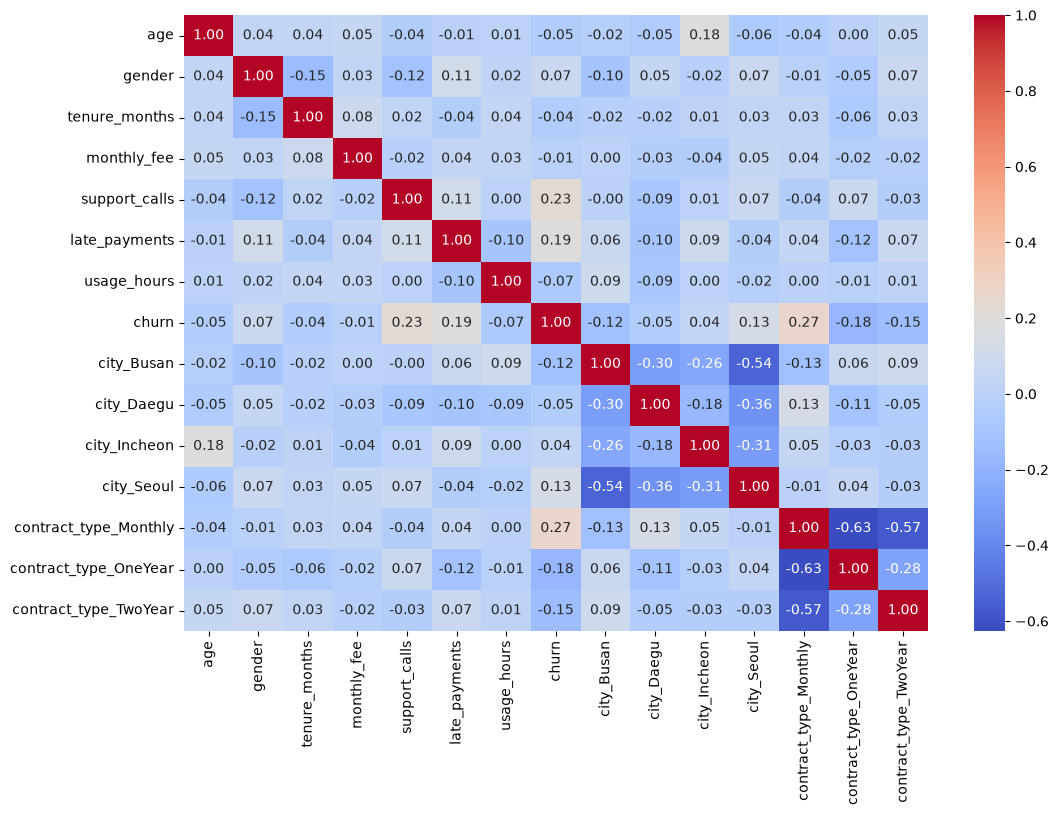

In [24]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.show()

In [25]:
# 예측 시 각 특성을 얼마나 중요하게 사용했는가
model.feature_importances_

array([0.11828742, 0.03316627, 0.12964433, 0.14662578, 0.14306509,
       0.10522141, 0.17105205, 0.01637186, 0.00895857, 0.02151974,
       0.02101742, 0.04708414, 0.02074269, 0.01724323])

In [26]:
balanced_model.feature_importances_

array([0.11284099, 0.04030555, 0.13911528, 0.15540667, 0.13683804,
       0.08677713, 0.1405746 , 0.01591392, 0.01202547, 0.01460042,
       0.02809053, 0.0699091 , 0.02509851, 0.02250379])

In [27]:
importance = pd.Series(
        model.feature_importances_,
        index=x.columns
)

importance = importance.sort_values(ascending=False)
importance

usage_hours              0.171052
monthly_fee              0.146626
support_calls            0.143065
tenure_months            0.129644
age                      0.118287
late_payments            0.105221
contract_type_Monthly    0.047084
gender                   0.033166
city_Incheon             0.021520
city_Seoul               0.021017
contract_type_OneYear    0.020743
contract_type_TwoYear    0.017243
city_Busan               0.016372
city_Daegu               0.008959
dtype: float64

In [28]:
importance2 = pd.Series(
    balanced_model.feature_importances_,
    index=x.columns
)

importance2 = importance2.sort_values(ascending=False)
importance2

monthly_fee              0.155407
usage_hours              0.140575
tenure_months            0.139115
support_calls            0.136838
age                      0.112841
late_payments            0.086777
contract_type_Monthly    0.069909
gender                   0.040306
city_Seoul               0.028091
contract_type_OneYear    0.025099
contract_type_TwoYear    0.022504
city_Busan               0.015914
city_Incheon             0.014600
city_Daegu               0.012025
dtype: float64

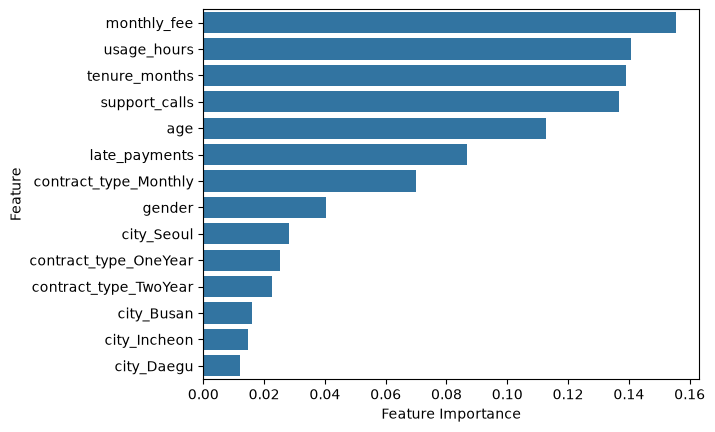

In [29]:
sns.barplot(
    x=importance2.values,
    y=importance2.index
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.show()

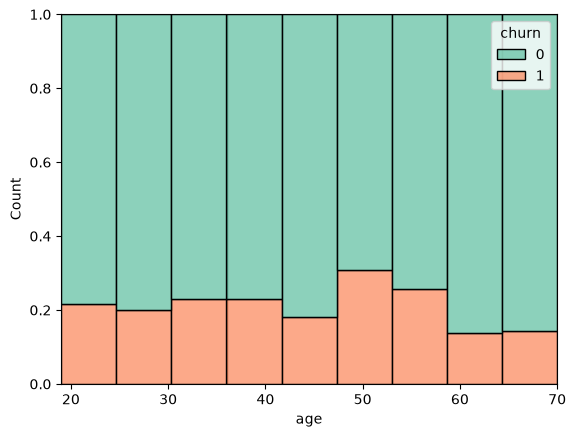

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=df, x='age', hue='churn', multiple='fill', palette='Set2')
plt.show()